# Extracting sites

Pulling a model timeseries out at a set of site coordinates is easy to get wrong by
hand, especially near coastlines.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)
case.load('TS', timespan=(1, 10), verbose=False)

# EOFs need a regular grid, so regrid off the spectral-element grid first
ts = case.ds['TS'].x.regrid(2, 2).x.da
print(dict(ts.sizes))

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


{'time': 120, 'lat': 90, 'lon': 180}


## Extracting sites

`.x.nearest2d()` finds the nearest **non-NaN** grid cell to each target coordinate, which
matters over the ocean: the nearest cell to a coastal site may be land. It returns a
`site` dimension so a whole proxy network comes back as one array.

In [3]:
sites = {
    'equatorial Pacific': (0.0, 220.0),
    'north Atlantic':     (55.0, 330.0),
    'southern ocean':     (-60.0, 90.0),
}
lats = [v[0] for v in sites.values()]
lons = [v[1] for v in sites.values()]

pts = ts.x.nearest2d(lat=lats, lon=lons)
print(dict(pts.sizes))
for i, name in enumerate(sites):
    p = pts.isel(site=i)
    print(f'  {name:20s} nearest cell at lat={float(p.lat):+6.1f}, lon={float(p.lon):6.1f}'
          f'  mean TS = {float(p.mean()):.2f} K')

{'site': 3, 'time': 120}


  equatorial Pacific   nearest cell at lat=  -1.0, lon= 219.0  mean TS = 304.40 K


  north Atlantic       nearest cell at lat= +55.0, lon= 329.0  mean TS = 285.79 K


  southern ocean       nearest cell at lat= -61.0, lon=  89.0  mean TS = 284.37 K


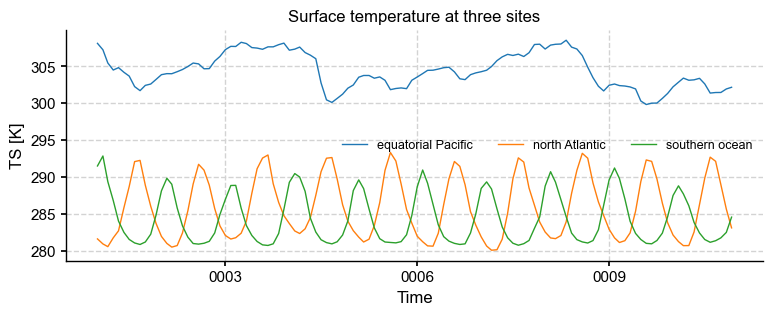

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
for i, name in enumerate(sites):
    ax.plot(pts.time, pts.isel(site=i), lw=1, label=name)
ax.legend(frameon=False, ncol=3, fontsize=9)
ax.set(xlabel='Time', ylabel='TS [K]', title='Surface temperature at three sites')
x4c.showfig(fig)

### Three-dimensional sites

`.x.nearest3d()` does the same in depth as well, combining horizontal great-circle
distance with the vertical offset. It works straight on the native POP grid, where
latitude and longitude are 2-D arrays.

Target depths are given in metres; `depth_unit` describes the model coordinate
(`'cm'` for POP).

In [5]:
case.load('TEMP', timespan=(1, 1), verbose=False)
temp = case.ds['TEMP'].x.da

pts3 = temp.x.nearest3d(
    lat=[0.0, -60.0], lon=[220.0, 90.0], depth=[25.0, 75.0],
    lat_coord='TLAT', lon_coord='TLONG', lat_dim='nlat', lon_dim='nlon',
    depth_coord='z_t', depth_dim='z_t', depth_unit='cm',
)
print(dict(pts3.sizes))
for i in range(pts3.sizes['site']):
    p = pts3.isel(site=i)
    print(f'  site {i}: lat={float(p.TLAT):+6.1f} lon={float(p.TLONG):6.1f} '
          f'z={float(p.z_t) / 100:6.1f} m  mean TEMP = {float(p.mean()):.2f} degC')

{'site': 2, 'time': 12}


  site 0: lat=  -0.3 lon= 219.6 z=  25.0 m  mean TEMP = 30.30 degC


  site 1: lat= -60.1 lon=  90.3 z=  75.0 m  mean TEMP = 8.50 degC
